# AskMyBookmark — Orchestrator Pattern POC

This notebook builds a **LangGraph orchestrator** (supervisor pattern) for searching starred GitHub repositories.

## Architecture

The key insight guiding this design: **keyword extraction → synonym generation is always a fixed,
sequential pipeline** — there is no routing decision to make. Exposing them as separate agent tools
would let the LLM call them out of order or skip one. Instead they form a deterministic
**Query Prep sub-workflow** that always runs first.

The **Supervisor** is the only true agent: it reads the (now-enriched) state and decides which
retriever to invoke.

```
User Query
    │
    ▼
┌──────────────────────────────────────────────────────┐
│                   query_prep                         │
│  (single LLM call: keyword extraction + synonym      │
│   expansion + route decision + include_curated)      │
└──────────────────────────────────────────────────────┘
    │                         │
    ▼ (pure keywords only)    ▼ (default — everything else)
lexical_search           ensemble_search
(MultiMatch BM25          (EnsembleRetriever:
 + legacy BM25,            MultiMatch BM25
 union-dedup)              + Qdrant dense, RRF)
    │                         │
    └───────────┬─────────────┘
                ▼
          merge_results
          (dedup pool of up to RETRIEVER_K=15 candidates)
                │
                ▼
         classify_curated
         (gpt-4o-mini batch classifier, 8+8 few-shot examples;
          writes is_curated_llm bool into each doc's metadata)
                │
                ▼
         filter_results
         (remove curated lists if include_curated=False;
          primary: is_curated_llm, fallback: BM25 score ≥ 4.0,
          safety net prevents empty result sets)
                │
                ▼
         rerank_results
         (listwise gpt-4o-mini reranker → trim to top_k)
                │
                ▼
         generate_answer
                │
                ▼
             Response
```

## Routing Heuristic

| Route | When to use |
|---|---|
| `ensemble` | **Default.** Any natural language, conceptual, or mixed query |
| `lexical` | Query is *literally just keywords* — no sentence structure (e.g. `"pytorch transformers"`) |

## State Shape

| Field | Populated by | Used by |
|---|---|---|
| `query` | user input | `keyword_extractor`, `ensemble_search`, `generate_answer` |
| `keywords` | `keyword_extractor` | `synonym_generator`, `lexical_search`, `ensemble_search` |
| `expansions` | `synonym_generator` | (debugging / display) |
| `bm25_terms` | `synonym_generator` | `lexical_search`, `ensemble_search` |
| `route` | `supervisor` | conditional edge routing |
| `include_curated` | `supervisor` | `classify_curated`, `filter_results` (keep or remove curated-list repos) |
| `bm25_results` | `lexical_search` / `ensemble_search` | `merge_results` |
| `vector_results` | (always empty — fused results go in `bm25_results`) | `merge_results` |
| `merged_results` | `merge_results` | `generate_answer` |
| `answer` | `generate_answer` | end user |


## 1. Imports & Environment Setup

In [1]:
import os
import pickle
import re
import uuid
from functools import partial
from typing import List, Dict, Any, Literal

import nest_asyncio
import numpy as np
import pandas as pd
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from pydantic import BaseModel, Field, ConfigDict
from textacy import preprocessing
from typing import TypedDict

from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from searcharray import SearchArray

nest_asyncio.apply()

# load environment variables — try notebooks/.env first (local dev), then root .env
for _env_path in ["notebooks/.env", ".env"]:
    if os.path.exists(_env_path):
        load_dotenv(_env_path)
        break

# download NLTK data if not already present
for _pkg in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(_pkg, quiet=True)

print("Imports OK")

Imports OK


## 2. Shared State

All nodes read from and write to a single `OrchestratorState` dict.  LangGraph merges the
partial dicts returned by each node into this shared state, so each node only needs to
return the keys it modifies.

In [2]:
class OrchestratorState(TypedDict):
    # ── Input ────────────────────────────────────────────────────────────────
    query: str                     # original user query (verbatim)

    # ── Query Prep (populated by deterministic sub-workflow) ─────────────────
    keywords: List[str]            # signal-bearing terms extracted from query
    expansions: List[Dict]         # per-keyword synonym objects (for inspection)
    bm25_terms: List[str]          # flat synonym list used to expand BM25 query

    # ── Supervisor ───────────────────────────────────────────────────────────
    route: str                     # "lexical" | "ensemble"
    include_curated: bool          # whether to include curated-list repos in results

    # ── Retrieval results ────────────────────────────────────────────────────
    bm25_results: List[Document]
    vector_results: List[Document]
    merged_results: List[Document]

    # ── User-controlled output size ───────────────────────────────────────────
    # Set at invocation time; defaults to 10 if not provided.
    # Retrievers always over-fetch (RETRIEVER_K candidates) internally.
    top_k: int

    # ── User feedback loop ────────────────────────────────────────────────────
    # feedback:           current-round ratings: repo → "good" | "meh" | "bad"
    # blocklist:          repos rated ☹️ across all rounds — never shown again
    # good_repos:         repos rated 😃 — carried forward into every round
    # feedback_iteration: 0 = first run; 1–3 = feedback refinement rounds
    feedback:           Dict[str, str]
    blocklist:          List[str]
    good_repos:         List[Document]
    feedback_iteration: int

    # ── Final output ─────────────────────────────────────────────────────────
    answer: str

## 3. Query Prep — Combined Single-Call Node

The `query_prep` node handles keyword extraction, synonym expansion, **and** routing in a
**single `gpt-4o-mini` call** using a combined `QueryPrepOutput` structured output schema.

### Why combine all three into one call?

The original design had three sequential nodes — `keyword_extractor → synonym_generator → supervisor`
— each waiting on the previous API round-trip.  But all three are really the same thing: *structured
extraction tasks on the same input (the user query)*.  None of them need external tool calls or
back-and-forth reasoning.  Combining them into one call saves ~2 sequential round-trips per query.

### Is the routing decision safe to make from the raw query alone?

Yes.  The routing decision (`lexical` vs `ensemble`) is a **structural** observation about the query —
"is this literally bare keywords, or does it have sentence structure?"  That is fully visible in the
raw query.  The node doesn't need pre-computed keywords to answer it.

Similarly, `include_curated` is an **intent** observation — "is the user asking for a curated list?" —
which is also clear from the raw query.

### Design note: keyword extraction is idempotent on keyword-only queries

For a query that is *already* just keywords (e.g. `"pytorch transformers"`), the extractor returns
them unchanged.  The routing decision handles the rest.

In [3]:
# ── Structured output schemas ─────────────────────────────────────────────────

class KeywordExpansion(BaseModel):
    keyword: str = Field(description="The original extracted keyword.")
    synonyms: List[str] = Field(
        description="Synonyms and closely related technical terms for this keyword "
                    "in the context of GitHub repos."
    )


class QueryPrepOutput(BaseModel):
    """Combined output for keyword extraction, synonym expansion, and routing."""
    keywords: List[str] = Field(
        description=(
            "Signal-bearing keywords extracted from the query: repo names, technology "
            "names, programming languages, domain terms, and action verbs. Strip "
            "conversational filler, pronouns, stopwords, and words related to "
            "'repositories', 'repos', 'GitHub', 'favorites', or 'starred'."
        )
    )
    expansions: List[KeywordExpansion] = Field(
        description="Per-keyword synonym expansions."
    )
    bm25_terms: List[str] = Field(
        description=(
            "Flat list of all synonyms collected from expansions, used to expand "
            "the BM25 query. Do not repeat the original keywords here."
        )
    )
    route: Literal["lexical", "ensemble"] = Field(
        description=(
            "Search strategy. Choose 'lexical' ONLY when the query is literally just "
            "bare keywords with no sentence structure, verbs, or question words "
            "(e.g. 'pytorch transformers cuda'). Choose 'ensemble' for everything "
            "else — natural language, conceptual, mixed, or ambiguous queries. "
            "When in doubt, always choose 'ensemble'."
        )
    )
    include_curated: bool = Field(
        description=(
            "True ONLY when the user explicitly asks for lists, resources, collections, "
            "courses, or curated roundups (e.g. 'show me awesome lists for deep learning', "
            "'find me a course on X'). False for all other queries where the user wants "
            "a specific tool, library, or implementation — not a collection of links."
        )
    )
    reasoning: str = Field(
        description="One sentence explaining the route and include_curated decisions."
    )


# ── System prompt ──────────────────────────────────────────────────────────────

QUERY_PREP_SYSTEM_PROMPT = """\
You are the query preparation agent for AskMyBookmark — a search assistant over a user's \
starred GitHub repositories.

Given a user query, perform four tasks in a single response:

## 1. Extract keywords
Extract only the signal-bearing terms: repo names, technology names, programming languages, \
domain terms, and action verbs. Strip conversational filler, pronouns, and stopwords. \
Ignore words related to "repositories", "repos", "GitHub", "favorites", or "starred".

## 2. Expand with synonyms
For each extracted keyword, generate relevant synonyms and closely related technical terms \
in the context of software, science, technology, and GitHub repositories. \
Do not duplicate the original keyword in the synonyms list. \
Collect all synonyms into bm25_terms as a flat list.

## 3. Choose a search strategy (route)
- "ensemble" (DEFAULT): any natural language, conceptual, mixed, or sentence-structure query. \
  Use this for the vast majority of queries.
- "lexical": ONLY when the query is literally bare keywords — no sentence structure, no verbs, \
  no question words (e.g. "pytorch transformers cuda"). When in doubt, prefer "ensemble".

## 4. Decide on curated list inclusion (include_curated)
Set True ONLY when the user explicitly asks for lists, resources, collections, courses, or \
curated roundups. Set False (default) when the user wants a specific tool, library, \
framework, or implementation.
"""

# ── LLM with structured output ────────────────────────────────────────────────

_query_prep_llm = ChatOpenAI(model="gpt-4o-mini").with_structured_output(QueryPrepOutput)


# ── Graph node ────────────────────────────────────────────────────────────────

def query_prep(state: OrchestratorState) -> dict:
    """Single LLM call: keyword extraction + synonym expansion + routing.

    Replaces the three sequential keyword_extractor → synonym_generator → supervisor
    nodes with one round-trip, saving ~2 API calls per query.
    """
    result: QueryPrepOutput = _query_prep_llm.invoke([
        SystemMessage(content=QUERY_PREP_SYSTEM_PROMPT),
        HumanMessage(content=state["query"]),
    ])
    # Guard: if the LLM didn't populate bm25_terms, derive it from expansions
    bm25_terms = result.bm25_terms or [
        syn for exp in result.expansions for syn in exp.synonyms
    ]
    print(
        f"[query_prep] keywords={result.keywords}  route={result.route!r}  "
        f"include_curated={result.include_curated}  reason: {result.reasoning}"
    )
    return {
        "keywords":       result.keywords,
        "expansions":     [exp.model_dump() for exp in result.expansions],
        "bm25_terms":     bm25_terms,
        "route":          result.route,
        "include_curated": result.include_curated,
    }


def route_after_query_prep(state: OrchestratorState) -> str:
    """Conditional edge function — maps route decision to the next node name."""
    return {"lexical": "lexical_search", "ensemble": "ensemble_search"}[state["route"]]


# ── Feedback refinement node ──────────────────────────────────────────────────

FEEDBACK_REFINEMENT_SYSTEM_PROMPT = """\
You are the query refinement agent for AskMyBookmark.

The user ran a search and gave emoji feedback on the results:

  😃 (good)  — These repos satisfy the user's need. Use their descriptions,
                topics, and names to generate new search terms that find MORE
                repos like these.

  😑 (meh)   — Tangentially relevant but not ideal. Try to surface better
                alternatives — but you can still include these if nothing
                better exists.

  ☹️ (bad)   — These actively frustrate the user. Analyse WHY they are wrong
                (wrong type? wrong language? wrong abstraction level? curated
                list when a real project was wanted?) and avoid those patterns.

Your job is to produce a refined QueryPrepOutput that:
1. Introduces new keywords and synonyms inspired by the 😃 repos.
2. Avoids vocabulary and topic patterns common to the ☹️ repos.
3. Updates route and include_curated if the feedback reveals a clear pattern
   (e.g. if all ☹️ repos are curated lists → set include_curated=False).

Keep the original query intent — do not drift into unrelated topics.
"""


def refine_query(state: OrchestratorState) -> dict:
    """LLM-driven query refinement using emoji feedback as positive/negative anchors.

    Reuses _query_prep_llm with a feedback-aware system prompt.  Sends 😃 repos
    as positive anchors (find more like these) and ☹️ repos as negative anchors
    (understand why they failed and avoid those patterns).  Outputs refreshed
    keywords, bm25_terms, route, and include_curated for the next search round.
    """
    feedback = state.get("feedback") or {}
    merged   = state.get("merged_results") or []

    good = [d for d in merged if feedback.get(d.metadata.get("repo")) == "good"]
    bad  = [d for d in merged if feedback.get(d.metadata.get("repo")) == "bad"]
    meh  = [d for d in merged if feedback.get(d.metadata.get("repo")) == "meh"]

    def _repo_line(doc: Document) -> str:
        m = doc.metadata
        return (
            f"  - {m.get('repo', 'unknown')}: {m.get('description', 'N/A')}\n"
            f"    Topics: {', '.join(m.get('topics', []))}"
        )

    parts = [f"Original query: {state['query']}\n"]
    if good:
        parts.append("😃 REPOS THE USER LIKED (find more like these):")
        parts.extend(_repo_line(d) for d in good)
    if bad:
        parts.append("\n☹️ REPOS THE USER DISLIKED (avoid these patterns):")
        parts.extend(_repo_line(d) for d in bad)
    if meh:
        parts.append("\n😑 REPOS THE USER WAS MEH ABOUT (try to find better):")
        parts.extend(_repo_line(d) for d in meh)

    result: QueryPrepOutput = _query_prep_llm.invoke([
        SystemMessage(content=FEEDBACK_REFINEMENT_SYSTEM_PROMPT),
        HumanMessage(content="\n".join(parts)),
    ])
    bm25_terms = result.bm25_terms or [
        syn for exp in result.expansions for syn in exp.synonyms
    ]
    print(
        f"[refine_query] keywords={result.keywords}  route={result.route!r}  "
        f"include_curated={result.include_curated}  reason: {result.reasoning}"
    )
    return {
        "keywords":        result.keywords,
        "expansions":      [exp.model_dump() for exp in result.expansions],
        "bm25_terms":      bm25_terms,
        "route":           result.route,
        "include_curated": result.include_curated,
    }


print("query_prep + refine_query nodes defined")

query_prep + refine_query nodes defined


## 4. Data Loading & Index Building

We reuse the exact same retriever setup from `retrievers.ipynb`:

- **`MultiMatchBM25Retriever`** — a custom LangChain retriever wrapping SearchArray's per-field
  BM25 with boost weights (`repo` × 3, `topics` × 2, `description` × 1.5, `content` × 1.0).
- **Qdrant in-memory dense retriever** — OpenAI `text-embedding-3-small` embeddings stored in
  a local Qdrant instance, queried with cosine similarity.

Both retrievers are built once at notebook startup and shared across graph invocations.

In [4]:
# ── Text pre-processing (mirrors retrievers.ipynb / ask_my_bookmark.py) ────────

MAX_CHARACTERS = 30_000
NAMESPACE = uuid.NAMESPACE_URL


def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax while keeping inner text and emojis."""
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"`([^`]+)`", r"\1", text)
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(*, unicode_form: str = "NFC"):
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


_normalize_text = make_normalize_text_pipeline()


def repo_to_uuid(repo_name: str) -> str:
    return str(uuid.uuid5(NAMESPACE, repo_name))


def normalize_docs(docs: List[Dict[str, Any]]) -> str:
    content_str = "".join(doc["content"] + "\n\n" for doc in docs)
    truncated = content_str[:MAX_CHARACTERS] if len(content_str) > MAX_CHARACTERS else content_str
    return _normalize_text(truncated)


def preprocess_text(text: str | None) -> List[str]:
    """Tokenizer used by SearchArray BM25 — lowercase, remove stopwords, lemmatize."""
    if text is None:
        return []
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in tokens]


print("Text preprocessing helpers defined")

Text preprocessing helpers defined


In [5]:
# ── MultiMatchBM25Retriever (from retrievers.ipynb) ────────────────────────────

def multi_match_search(
    query: str,
    df: pd.DataFrame,
    columns: List[str],
    boosts: Dict[str, float] | None = None,
) -> pd.DataFrame:
    """BM25 multi-field search with per-field boost weights and dismax scoring."""
    if boosts is None:
        boosts = {}
    boost_values = {col: boosts.get(col, 1.0) for col in columns}

    tokenized_queries = {
        col: df[col].array.tokenizer(query)
        for col in columns
    }

    field_scores = {
        col: np.asarray([df[col].array.score(term) for term in tokenized_queries[col]])
             * boost_values[col]
        for col in columns
    }

    num_terms = max((len(s) for s in field_scores.values()), default=0)
    if num_terms == 0:
        result = df.copy()
        result["score"] = 0.0
        return result

    best_term_scores = []
    for term_idx in range(num_terms):
        term_scores = [
            field_scores[col][term_idx]
            for col in columns
            if term_idx < len(field_scores[col])
        ]
        best_term_scores.append(np.max(term_scores, axis=0))

    result = df.copy()
    result["score"] = np.sum(best_term_scores, axis=0)
    return result.sort_values("score", ascending=False)


class MultiMatchBM25Retriever(BaseRetriever):
    """LangChain-compatible retriever wrapping SearchArray multi-field BM25."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    search_df: pd.DataFrame
    columns: List[str]
    boosts: Dict[str, float]
    k: int = 10

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> List[Document]:
        results = multi_match_search(
            query=query,
            df=self.search_df,
            columns=self.columns,
            boosts=self.boosts,
        )
        top_k = results[results["score"] > 0].head(self.k)
        return [
            Document(
                page_content=row["content"],
                metadata={
                    "id":                row["id"],
                    "repo":              row["repo"],
                    "description":       row["description"],
                    "topics":            row.get("topics_list", row["topics"].split()),
                    "language":          row.get("language"),
                    "stars":             row.get("stars"),
                    "url":               row.get("url"),
                    "curated_list_bm25": float(row.get("curated_list_bm25", 0.0)),
                    "score":             float(row["score"]),
                },
            )
            for _, row in top_k.iterrows()
        ]


print("MultiMatchBM25Retriever defined")

MultiMatchBM25Retriever defined


In [6]:
# ── Load cached GitHub data ───────────────────────────────────────────────────

with open("../data/cached/github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

print(f"Loaded {len(starred_repo_data)} starred repos")

# ── Build per-field search DataFrame ─────────────────────────────────────────

search_df = pd.DataFrame([
    {
        "id":          repo_to_uuid(repo["repo"]),
        "repo":        repo["repo"],
        "description": repo.get("description") or "",
        "topics":      " ".join(repo.get("topics", [])),
        "topics_list": repo.get("topics", []),       # kept as list for metadata pass-through
        "language":    repo.get("language"),
        "stars":       repo.get("stars"),
        "url":         repo.get("url"),
        "content":     f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
    }
    for repo in starred_repo_data
])

# index each field with SearchArray for BM25 scoring
search_df["repo_idx"]        = SearchArray.index(search_df["repo"],        tokenizer=preprocess_text)
search_df["description_idx"] = SearchArray.index(search_df["description"], tokenizer=preprocess_text)
search_df["topics_idx"]      = SearchArray.index(search_df["topics"],      tokenizer=preprocess_text)
search_df["content_idx"]     = SearchArray.index(search_df["content"],     tokenizer=preprocess_text)

print(f"search_df built: {len(search_df)} rows")

Loaded 2049 starred repos
2026-03-17 05:25:48,881 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-17 05:25:48,882 - searcharray.indexing - INFO - 0 Batch Start tokenization
2026-03-17 05:25:48,882 - searcharray.indexing - INFO - Tokenizing 2049 documents
2026-03-17 05:25:50,358 - searcharray.indexing - INFO - Tokenization -- vstacking
2026-03-17 05:25:50,358 - searcharray.indexing - INFO - Tokenization -- DONE
2026-03-17 05:25:50,359 - searcharray.indexing - INFO - Inverting docs->terms
2026-03-17 05:25:50,360 - searcharray.indexing - INFO - Encoding positions to bit array
2026-03-17 05:25:50,363 - searcharray.indexing - INFO - Batch tokenization complete
2026-03-17 05:25:50,363 - searcharray.indexing - INFO - (main thread) Processing 1 batch results
2026-03-17 05:25:50,364 - searcharray.indexing - INFO - Indexing from tokenization complete
2026-03-17 05:25:50,365 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-17 05:25:50,366 - searcharray.ind

In [7]:
# ── Compute curated-list BM25 score (for document metadata) ──────────────────
#
# Repos that are themselves "awesome lists" get a boosted score stored in
# metadata so the answer generator can note it if relevant.

CURATED_QUERY = "awesome curated lists"
curated_results = multi_match_search(
    query=CURATED_QUERY,
    df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={"repo_idx": 3.0, "topics_idx": 2.0, "description_idx": 1.5, "content_idx": 1.0},
)
curated_score_by_id = dict(
    zip(curated_results["id"], curated_results["score"].astype(float))
)

# Attach curated_list_bm25 to search_df so MultiMatchBM25Retriever can pass it through
search_df["curated_list_bm25"] = search_df["id"].map(curated_score_by_id).fillna(0.0)

# ── Build LangChain Document objects (shared by both retrievers) ──────────────

documents = [
    Document(
        page_content=f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
        metadata={
            "id":                (id_ := repo_to_uuid(repo["repo"])),
            "repo":              repo["repo"],
            "description":       repo.get("description") or "",
            "topics":            repo.get("topics", []),
            "language":          repo.get("language"),
            "doc_source":        repo.get("doc_source"),
            "stars":             repo.get("stars"),
            "url":               repo.get("url"),
            "curated_list_bm25": curated_score_by_id.get(id_, 0.0),
        },
    )
    for repo in starred_repo_data
]

# ── Over-fetch constant ───────────────────────────────────────────────────────
#
# All retrievers fetch RETRIEVER_K candidates so the listwise reranker has a
# larger pool to work from before trimming to the user's top_k.  RETRIEVER_K
# should always be >= the maximum top_k a user might request.

RETRIEVER_K = 15

# ── Curated-list filtering thresholds ────────────────────────────────────────
#
# CURATED_FILTER_THRESHOLD: curated_list_bm25 scores at or above this are
#   treated as "definitely a curated list" and are hard-filtered from results
#   when the supervisor sets include_curated=False.
#
# CURATED_LABEL_THRESHOLD: scores at or above this are flagged as "Likely" a
#   curated list in the LLM context.  Lower than the filter threshold so the
#   answer LLM and reranker get a signal on borderline repos.
#
# Note: BM25 is an imperfect proxy — some curated lists score below 2.0 if
#   they don't use canonical "awesome / curated / list" keywords.  Labels are
#   intentionally probabilistic (Yes / Likely / Most likely not).

CURATED_FILTER_THRESHOLD = 4.0
CURATED_LABEL_THRESHOLD  = 2.0

# ── MultiMatchBM25 retriever ──────────────────────────────────────────────────

bm25_retriever = MultiMatchBM25Retriever(
    search_df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={
        "repo_idx":        3.0,
        "topics_idx":      2.0,
        "description_idx": 1.5,
        "content_idx":     1.0,
    },
    k=RETRIEVER_K,
)

# ── Qdrant in-memory dense retriever ─────────────────────────────────────────

print("Building Qdrant index — this may take a minute...")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="ask_my_bookmark",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="ask_my_bookmark",
    embedding=embeddings,
)
vector_store.add_documents(documents)
dense_retriever = vector_store.as_retriever(search_kwargs={"k": RETRIEVER_K})

# ── Ensemble retriever (RRF fusion of BM25 + dense) ──────────────────────────
#
# EnsembleRetriever combines results from both retrievers using Reciprocal Rank
# Fusion (RRF). Unlike running them sequentially and merging manually, RRF
# re-ranks by inverse rank position, giving a principled combined ranking.
# Used by the `ensemble_search` node when the supervisor routes to "ensemble".

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
)

# ── Legacy BM25 retriever (standard LangChain TF-IDF over full document text) ─
#
# Uses a different scoring algorithm than MultiMatchBM25Retriever — operates on
# the full document content rather than per-field boosted scoring.  Running both
# BM25 methods together for lexical search maximises recall: they surface
# different sets of candidate repos, as observed in retrievers.ipynb.

legacy_bm25_retriever = BM25Retriever.from_documents(documents)
legacy_bm25_retriever.k = RETRIEVER_K

print("All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)")

Building Qdrant index — this may take a minute...
All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)


## 5. Search Nodes

Two search nodes cover the two routing outcomes:

| Node | Retriever(s) | Query input |
|---|---|---|
| `lexical_search` | `MultiMatchBM25Retriever` + `BM25Retriever` (merged) | `keywords` + `bm25_terms` joined as one expanded string |
| `ensemble_search` | `EnsembleRetriever` (MultiMatch BM25 + Qdrant dense via RRF) | expanded BM25 query |

### Why two BM25 methods in `lexical_search`?

`MultiMatchBM25Retriever` uses per-field boost weights (repo name × 3, topics × 2, etc.) and
SearchArray's scoring.  The legacy `BM25Retriever` uses standard LangChain TF-IDF over the full
document content.  They surface **different** candidate repos — running both together and
deduplicating maximises lexical recall, as observed in `retrievers.ipynb`.

A single `lexical_search` node runs both internally (no routing decision needed) and merges
via union-dedup, preserving MultiMatch results first.

### Why `ensemble_search` is the default

`EnsembleRetriever` fuses MultiMatch BM25 + Qdrant dense via **Reciprocal Rank Fusion (RRF)**:
each document scores `1 / (rank + k)` from each leg, summed and re-ranked.  This covers
*both* exact-term precision and semantic recall in a single pass — better than either alone
for natural language queries.  The supervisor routes here unless the query is pure keywords.

> **Note on query string for ensemble:** `EnsembleRetriever` passes the same query string to
> all child retrievers.  We pass the **expanded BM25 query** (keywords + synonyms) so the
> BM25 leg gets full term expansion benefit.  The dense leg is robust enough that synonym
> terms in the query string do not meaningfully hurt embedding quality.

In [8]:
def _build_expanded_query(state: OrchestratorState) -> str:
    """Join extracted keywords + synonyms into a single expanded query string for BM25."""
    all_terms = state["keywords"] + state["bm25_terms"]
    return " ".join(all_terms)


def lexical_search(state: OrchestratorState) -> dict:
    """Run dual-BM25 lexical search: MultiMatchBM25 + legacy BM25, merged by union-dedup.

    Both retrievers use the keyword-expanded query (original keywords + synonyms).
    MultiMatchBM25 uses per-field boost weights; legacy BM25 uses full-document
    TF-IDF.  They surface different candidates, so running both maximises recall.
    Results are merged: MultiMatch first (field-boosted precision), then any
    legacy-only results appended.
    """
    expanded_query = _build_expanded_query(state)

    multi_results = bm25_retriever.invoke(expanded_query)
    legacy_results = legacy_bm25_retriever.invoke(expanded_query)

    # union-dedup: MultiMatch first, then append legacy-only results
    seen = {doc.metadata.get("repo") for doc in multi_results}
    extra = [doc for doc in legacy_results if doc.metadata.get("repo") not in seen]

    return {"bm25_results": multi_results + extra, "vector_results": []}


def ensemble_search(state: OrchestratorState) -> dict:
    """Run EnsembleRetriever (RRF fusion of MultiMatch BM25 + Qdrant dense).

    Default route for natural language and mixed queries.  Passes the expanded
    query (keywords + synonyms) so the BM25 leg benefits from term expansion
    while the dense leg remains robust to the extra terms.
    Results stored in bm25_results so merge_results passes them through unchanged.
    """
    expanded_query = _build_expanded_query(state)
    results = ensemble_retriever.invoke(expanded_query)
    return {"bm25_results": results, "vector_results": []}


print("Search nodes defined")

Search nodes defined


## 6. Search Nodes

The `query_prep` node already chose the route and wrote it into state.  The conditional edge
(`route_after_query_prep`) reads `state["route"]` and dispatches to the appropriate search node.

| Route | Node | When |
|---|---|---|
| `ensemble` | `ensemble_search` | **Default** — natural language, conceptual, or mixed queries |
| `lexical` | `lexical_search` | Query is *literally* bare keywords only |

In [9]:
# Routing and supervisor logic is now handled by query_prep (cell 6).
# route_after_query_prep (also in cell 6) serves as the conditional edge function.
print("Search nodes ready")

Search nodes ready


## 7. Merge, Rerank & Answer Generation

### `merge_results`

Deduplicates the over-fetched pool from the search nodes (up to `RETRIEVER_K` candidates)
into a single ordered list by union-dedup.  No trimming happens here — the full pool is
passed to the reranker.

### `rerank_results` (listwise LLM reranker)

A dedicated `gpt-4o-mini` call receives the full candidate pool and the original query and
returns a relevance-ranked ordering.  The reranker formats each candidate as a numbered
entry (repo name, description, topics, language) and asks the LLM to output the candidate
indices from most to least relevant.

**Why listwise over pairwise?**  A single LLM call handles all `n` candidates at once —
`O(1)` API calls vs `O(n²)` for full pairwise ELO.  Quality is comparable for a moderate
pool size (≤20 docs), and latency/cost are manageable.

After reranking, results are trimmed to `state["top_k"]` (default 10) before the answer
generator sees them.

### `generate_answer`

Uses the same RAG system prompt from `app/ask_my_bookmark.py` — grounding the LLM strictly
in the retrieved and reranked repository context.

In [10]:
# ── Merge node ────────────────────────────────────────────────────────────────

def merge_results(state: OrchestratorState) -> dict:
    """Deduplicate and merge BM25 + vector results.

    In feedback rounds, 😃 repos from previous rounds are prepended to the pool
    so they are always carried forward regardless of what the new retrieval finds.
    New candidates are appended after the preserved good repos.
    """
    # Carry 😃 repos from previous rounds — they always survive into the next round
    good_repos: List[Document] = state.get("good_repos") or []
    seen_repos: set = {doc.metadata.get("repo") for doc in good_repos}
    merged: List[Document] = list(good_repos)

    for doc in (state["bm25_results"] + state["vector_results"]):
        repo = doc.metadata.get("repo")
        if repo and repo not in seen_repos:
            seen_repos.add(repo)
            merged.append(doc)

    return {"merged_results": merged}


# ── Curated-list filter node ──────────────────────────────────────────────────

def filter_results(state: OrchestratorState) -> dict:
    """Remove curated-list repos from the candidate pool when include_curated=False.

    Primary signal:  is_curated_llm (bool) written by classify_curated — a
                     gpt-4o-mini few-shot classifier trained on 8+8 examples.
    Fallback signal: curated_list_bm25 >= CURATED_FILTER_THRESHOLD (4.0) — the
                     BM25-based score used when the LLM classifier did not run.

    A document is filtered out if EITHER signal marks it as a curated list.

    Safety net: if filtering would leave fewer than min(top_k, 3) results, skip
    the filter entirely and pass the full pool through.  This prevents empty or
    near-empty result sets when a niche query only matches curated list repos.
    """
    if state.get("include_curated", False):
        return {"merged_results": state["merged_results"]}

    candidates = state["merged_results"]
    top_k = state.get("top_k", 10)
    safety_floor = min(top_k, 3)

    # Remove ☹️-rated repos accumulated across feedback rounds
    blocklist: set = set(state.get("blocklist") or [])

    filtered = [
        doc for doc in candidates
        if doc.metadata.get("repo") not in blocklist
        and not doc.metadata.get("is_curated_llm", False)
        and doc.metadata.get("curated_list_bm25", 0.0) < CURATED_FILTER_THRESHOLD
    ]

    if len(filtered) < safety_floor:
        # Safety net: don't produce an empty result set — only skip the curated
        # filter (blocklist removals are always honoured even in the safety net)
        filtered_no_curated = [
            doc for doc in candidates
            if doc.metadata.get("repo") not in blocklist
        ]
        if len(filtered_no_curated) >= safety_floor:
            print(
                f"[filter_results] safety net: curated filter relaxed "
                f"({len(filtered)} → {len(filtered_no_curated)} results)"
            )
            return {"merged_results": filtered_no_curated}
        print(
            f"[filter_results] safety net: keeping all {len(candidates)} candidates "
            f"(floor={safety_floor})"
        )
        return {"merged_results": candidates}

    n_blocked   = sum(1 for d in candidates if d.metadata.get("repo") in blocklist)
    n_curated   = len(candidates) - len(filtered) - n_blocked
    print(
        f"[filter_results] removed {n_blocked} blocklisted + {n_curated} curated-list "
        f"repo(s), {len(filtered)} candidates remaining"
    )
    return {"merged_results": filtered}


# ── LLM curated-list classifier ───────────────────────────────────────────────

class _CuratedItem(BaseModel):
    index: int = Field(description="0-based index of the candidate in the input list")
    is_curated_list: bool = Field(
        description=(
            "True if the repo is a curated list/directory of external links; "
            "False if it is a real project delivering its own code, data, or content."
        )
    )
    reason: str = Field(description="Brief 5-10 word explanation for the classification")


class _CuratedClassifications(BaseModel):
    classifications: List[_CuratedItem] = Field(
        description="Classification for every candidate in the input list"
    )


CURATED_CLASSIFIER_SYSTEM_PROMPT = """\
You are a classifier that determines whether a GitHub repository is a **curated list** \
or a **real project**.

## Key Principle
A **curated list** is a repository whose primary value is aggregating links or references \
to external content (other repos, papers, tools, tutorials, courses, books). It acts as an \
index or directory.

A **real project** delivers its own original code, data, models, or written content. Even if \
it uses the words "curated", "collection", or "list" in its description, what matters is \
whether the repo IS the thing or merely points to other things.

## Examples of CURATED LISTS
[0] Repo: wsvincent/awesome-django
    Description: A curated list of awesome things related to Django
    Topics: awesome, awesome-list, django
    → CURATED: aggregates links to Django tools, packages, and tutorials.

[1] Repo: eugeneyan/applied-ml
    Description: Papers & tech blogs by companies sharing their work on data science & machine learning in production.
    Topics: applied-machine-learning, data-science, natural-language-processing
    → CURATED: aggregates external blog posts and papers; the repo itself contains no original code.

[2] Repo: Developer-Y/cs-video-courses
    Description: List of Computer Science courses with video lectures.
    Topics: algorithms, computer-science, machine-learning
    → CURATED: a directory of links to external video courses.

[3] Repo: NirDiamant/RAG_Techniques
    Description: This repository showcases various advanced techniques for Retrieval-Augmented Generation (RAG) systems.
    Topics: langchain, llm, rag, tutorials
    → CURATED: despite sounding like a project, it is a collection of tutorial notebooks — value is the curated index of examples, not a deployable tool.

[4] Repo: ossu/computer-science
    Description: Path to a free self-taught education in Computer Science!
    Topics: computer-science, curriculum, education
    → CURATED: a structured roadmap of links to external free courses; contains no original course content.

[5] Repo: ashishps1/learn-ai-engineering
    Description: Learn AI and LLMs from scratch using free resources
    Topics: ai, large-language-models, llm, machine-learning
    → CURATED: primary value is the aggregated collection of free external resources it links to.

[6] Repo: EbookFoundation/free-programming-books
    Description: Freely available programming books
    Topics: books, education, list
    → CURATED: a pure link collection; the "content" is pointers to books available elsewhere.

[7] Repo: codecrafters-io/build-your-own-x
    Description: Master programming by recreating your favorite technologies from scratch.
    Topics: programming, tutorial
    → CURATED: aggregates links to external "build your own X" tutorials; the repo is an index of those links.

## Examples of REAL PROJECTS

[8] Repo: explosion/curated-transformers
    Description: A PyTorch library of curated Transformer models and their composable components
    Topics: bert, llm, nlp, pytorch, transformer
    → REAL PROJECT: despite "curated" in the name, this IS a usable PyTorch library — the code is the value.

[9] Repo: google-deepmind/mujoco_menagerie
    Description: A collection of high-quality models for the MuJoCo physics engine, curated by Google DeepMind.
    Topics: mujoco, robotics
    → REAL PROJECT: the model files (XML/MJCF) ARE the deliverable; "curated" describes quality, not a link directory.

[10] Repo: h5bp/Front-end-Developer-Interview-Questions
     Description: A list of helpful front-end related questions you can use to interview potential candidates.
     Topics: css-questions, front-end, html-questions, interview-questions
     → REAL PROJECT: the questions themselves are the original written content — not links to external question banks.

[11] Repo: faridrashidi/kaggle-solutions
     Description: Collection of Kaggle Solutions and Ideas
     Topics: kaggle, machine-learning, solutions
     → REAL PROJECT: contains actual solution code notebooks; not links to external Kaggle submissions.

[12] Repo: openai/spinningup
     Description: An educational resource to help anyone learn deep reinforcement learning.
     Topics: deep-reinforcement-learning, machine-learning, reinforcement-learning
     → REAL PROJECT: despite "educational resource" phrasing, it contains actual RL algorithm implementations in code.

[13] Repo: huggingface/transformers
     Description: The model-definition framework for state-of-the-art machine learning models in text, vision, audio.
     Topics: deep-learning, llm, machine-learning, nlp, pytorch
     → REAL PROJECT: a full ML framework delivering original software.

[14] Repo: weaviate/weaviate
     Description: Weaviate is an open-source vector database that stores both objects and vectors.
     Topics: vector-database, vector-search, semantic-search
     → REAL PROJECT: a deployable database system with its own code.

[15] Repo: argilla-io/argilla
     Description: Argilla is a collaboration tool for AI engineers and domain experts to build high-quality datasets
     Topics: annotation-tool, llm, nlp, text-labeling
     → REAL PROJECT: a specific tool with real application code — not a link directory.

## Task
For each candidate below, classify it as a curated list or a real project.
Output JSON with a "classifications" array covering EVERY candidate index provided.
"""

_curator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(
    _CuratedClassifications
)

# ── Regex fast-path patterns ──────────────────────────────────────────────────
# These catch the unambiguous cases instantly, with no LLM call.

# Positive: description signals that clearly indicate a curated list
_CURATED_POSITIVE_DESC_RE = re.compile(
    r"(?:"
    r"curated list of"
    r"|\blist of\b.{0,100}\b(?:tools|resources|tutorials|papers|courses|links|examples|"
    r"projects|repos|repositories|books|videos|algorithms|frameworks|libraries|datasets)\b"
    r"|\bcollection of\b.{0,100}\b(?:resources|tutorials|papers|tools|links|examples|"
    r"courses|books|videos)\b"
    r"|\bfreely available\b.{0,40}\bbooks\b"
    r"|\b\d{2,4}\+?\s+\w[\w\s,/]+projects with code\b"
    r"|\bindex of\b.{0,80}\b(?:algorithms|papers|resources|tools|courses)\b"
    r")",
    re.IGNORECASE,
)

# Positive: topics that are unambiguous curated-list signals
_CURATED_POSITIVE_TOPICS = frozenset({"awesome-list", "curated-list", "curated-lists"})

# Positive: repo names following the awesome-* convention
_CURATED_AWESOME_REPO_RE = re.compile(r"^[^/]+/awesome[-_]", re.IGNORECASE)

# Negative: description phrases that strongly indicate a real project
_NOT_CURATED_DESC_RE = re.compile(
    r"(?:"
    r"\bis (?:an? )?(?:open.?source |fast |lightweight |simple )?(?:library|framework|engine|database|platform|sdk|cli|toolkit)\b"
    r"|official (?:pytorch|tensorflow|jax|keras) implementation\b"
    r"|\bpython (?:library|package|wrapper|client)\b"
    r"|workflow engine\b"
    r")",
    re.IGNORECASE,
)

# Weak positive signals — if these appear in description, don't auto-label as NOT-curated
_WEAK_POSITIVE_DESC_RE = re.compile(
    r"\b(?:list|collection|resource|tutorial|paper|course|curated|survey|index|roundup)\b",
    re.IGNORECASE,
)


def _quick_curated_check(m: dict):
    """Fast rule-based curated-list check. Returns True, False, or None (ambiguous).

    Only fires on high-confidence signals to avoid false positives/negatives.
    Ambiguous cases (None) are routed to the LLM stage.
    """
    description = (m.get("description") or "").strip()
    topics      = set(m.get("topics") or [])
    repo        = (m.get("repo") or "")

    # ── Obvious curated signals ───────────────────────────────────────────────
    if _CURATED_POSITIVE_TOPICS & topics:
        return True
    if _CURATED_AWESOME_REPO_RE.match(repo):
        return True
    if description and _CURATED_POSITIVE_DESC_RE.search(description):
        return True

    # ── Obvious NOT-curated signals (conservative) ────────────────────────────
    # Only fire when the description clearly self-identifies as a project AND
    # there are no weak curated-list signals in the description.
    if description and _NOT_CURATED_DESC_RE.search(description):
        if not _WEAK_POSITIVE_DESC_RE.search(description):
            return False

    return None  # genuinely ambiguous — needs LLM


def classify_curated(state: OrchestratorState) -> dict:
    """Two-stage curated-list classifier.

    Stage 1 — Regex fast-path (zero LLM cost):
        Instantly classifies obvious curated lists (awesome-list topics, "curated list
        of" descriptions, awesome-* repo names) and obvious real projects (clear
        library/framework/engine descriptions with no list vocabulary). In typical
        queries this resolves 8–12 of the 15 candidates immediately.

    Stage 2 — Batch LLM call (only for ambiguous candidates):
        Sends the remaining 3–7 ambiguous candidates to gpt-4o-mini with the 8+8
        few-shot prompt. Much shorter prompt than sending all 15, so faster and cheaper.
        If all candidates were resolved in Stage 1, this LLM call is skipped entirely.

    Skipped entirely when include_curated=True.
    Falls back gracefully as a no-op if the LLM call fails.
    """
    if state.get("include_curated", False):
        return {}

    candidates = state["merged_results"]
    if not candidates:
        return {}

    # Copy docs to avoid mutating shared state
    classified_docs = [
        Document(page_content=d.page_content, metadata=dict(d.metadata))
        for d in candidates
    ]

    # ── Stage 1: Regex fast-path ──────────────────────────────────────────────
    ambiguous_indices = []
    n_regex_curated = 0
    n_regex_not_curated = 0

    for i, doc in enumerate(classified_docs):
        result = _quick_curated_check(doc.metadata)
        if result is True:
            doc.metadata["is_curated_llm"] = True
            doc.metadata["is_curated_reason"] = "regex: obvious curated signal"
            n_regex_curated += 1
        elif result is False:
            doc.metadata["is_curated_llm"] = False
            doc.metadata["is_curated_reason"] = "regex: obvious real project"
            n_regex_not_curated += 1
        else:
            ambiguous_indices.append(i)

    print(
        f"[classify_curated] regex: {n_regex_curated} curated, "
        f"{n_regex_not_curated} not-curated, {len(ambiguous_indices)} ambiguous"
    )

    if not ambiguous_indices:
        return {"merged_results": classified_docs}  # zero LLM calls needed

    # ── Stage 2: LLM call for ambiguous candidates only ───────────────────────
    candidate_lines = []
    for i in ambiguous_indices:
        m = classified_docs[i].metadata
        topics_str = ", ".join(m.get("topics", [])) or "none"
        candidate_lines.append(
            f"[{i}] Repo: {m.get('repo', 'unknown')}\n"
            f"     Description: {m.get('description', '') or 'N/A'}\n"
            f"     Topics: {topics_str}"
        )
    candidates_text = "\n\n".join(candidate_lines)

    try:
        result: _CuratedClassifications = _curator_llm.invoke([
            SystemMessage(content=CURATED_CLASSIFIER_SYSTEM_PROMPT),
            HumanMessage(content=f"Candidates to classify:\n\n{candidates_text}"),
        ])
        for item in result.classifications:
            if item.index in ambiguous_indices:
                classified_docs[item.index].metadata["is_curated_llm"] = item.is_curated_list
                classified_docs[item.index].metadata["is_curated_reason"] = item.reason

        n_llm_curated = sum(1 for item in result.classifications if item.is_curated_list)
        print(
            f"[classify_curated] LLM: {n_llm_curated}/{len(ambiguous_indices)} "
            f"ambiguous flagged as curated"
        )
    except Exception as exc:
        print(f"[classify_curated] LLM fallback to BM25 signal (error: {exc})")

    return {"merged_results": classified_docs}


# ── RAG system prompt (from ask_my_bookmark.py) ────────────────────────────────

RAG_SYSTEM_PROMPT = """You are AskMyBookmark, a personal research assistant with access to the user's GitHub starred repositories.

Your job is to help the user discover, recall, and explore repositories they have bookmarked on GitHub. You answer questions by reasoning over the retrieved repository context provided to you — not from your general knowledge of what exists on GitHub.

**Ground rules:**
- Only surface repositories that appear in the retrieved context below. Do not invent or suggest repositories that are not present in the context.
- If no retrieved repositories are relevant to the query, say so honestly and suggest the user try rephrasing or broadening their search.
- You may use your general knowledge to explain a topic or technology, but all repository recommendations must come exclusively from the retrieved context.

**Format your response as a strict numbered list from 1 to {n_results}.**
- Every number from 1 to {n_results} must appear exactly once. Do not skip any number.
- Each numbered entry must correspond to exactly one repository from the context, in the order they are listed (already ranked best-first).
- Do not add a closing paragraph summarising which repos were "most relevant" or noting that others were omitted — every entry must appear in the numbered list.

**For each numbered entry include:**
- The repository's full name as a markdown link: [owner/repo](URL)
- A brief description of what it does, in your own words.
- 1–2 sentences on *why* it is relevant to the user's query.
- Optionally: language, star count, or topics if they help the user evaluate the match.
"""

RAG_HUMAN_PROMPT_TEMPLATE = """User query: {query}

Retrieved repositories ({n_results} total, already ranked best-first):
Format your answer as a numbered list from 1 to {n_results}. Every number must appear.
{context}
"""

_rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(RAG_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template(RAG_HUMAN_PROMPT_TEMPLATE),
])

_answer_llm = ChatOpenAI(model="gpt-4o-mini")
_rag_chain = _rag_prompt | _answer_llm


def _curated_label(m: dict) -> str:
    """Return a human-readable curated-list label for the given document metadata.

    Prefers the LLM classification (is_curated_llm) when available; falls back
    to the BM25-derived score with graded thresholds.
    """
    if "is_curated_llm" in m:
        return "Yes" if m["is_curated_llm"] else "Most likely not"
    score = m.get("curated_list_bm25", 0.0)
    if score >= CURATED_FILTER_THRESHOLD:
        return "Yes"
    if score >= CURATED_LABEL_THRESHOLD:
        return "Likely"
    return "Most likely not"


def _format_context(docs: List[Document]) -> str:
    """Serialise retrieved docs into the context block passed to the LLM."""
    parts = []
    for doc in docs:
        m = doc.metadata
        repo = m.get("repo", "unknown")
        # Fall back to constructing the URL from the repo name if the stored
        # url field is absent or None (GitHub URLs are always predictable).
        url = m.get("url") or f"https://github.com/{repo}"
        language = m.get("language") or "unknown"
        stars    = m.get("stars")
        stars_str = f"{stars:,}" if isinstance(stars, (int, float)) and stars else "unknown"
        parts.append(
            f"Repo: {repo}\n"
            f"URL: {url}\n"
            f"Description: {m.get('description', '')}\n"
            f"Topics: {', '.join(m.get('topics', []))}\n"
            f"Language: {language}\n"
            f"Stars: {stars_str}\n"
            f"Curated list: {_curated_label(m)}\n"
            "---"
        )
    return "\n".join(parts)


def generate_answer(state: OrchestratorState) -> dict:
    """Generate a grounded answer from the reranked, top-k-trimmed documents."""
    docs = state["merged_results"]
    context = _format_context(docs)
    response = _rag_chain.invoke({
        "query":     state["query"],
        "context":   context,
        "n_results": len(docs),
    })
    return {"answer": response.content}


# ── Listwise LLM reranker ─────────────────────────────────────────────────────

class RerankedList(BaseModel):
    ranked_indices: List[int] = Field(
        description=(
            "1-based indices of the candidates ordered from most relevant to least "
            "relevant for the given query.  Include every candidate index exactly once."
        )
    )


RERANKER_SYSTEM_PROMPT = """\
You are a search result reranker for AskMyBookmark, an assistant that searches a user's
starred GitHub repositories.

You will be given a user query and a numbered list of repository candidates.
Each candidate includes a "Curated list" field that tells you whether the repository is a
curated collection of links/resources (Yes) or an actual project/library/tool (Most likely not).

Your task is to reorder the candidates from most relevant to least relevant for the query.

Guidelines:
- Consider the repo name, description, topics, programming language, and curated-list status.
- A candidate is highly relevant if it directly addresses the query's intent.
- When candidates are closely matched, prefer repos that are more specific to the query.
- Curated list handling:
    * If the query is asking for a specific tool, library, or implementation (the common case),
      rank curated lists BELOW specific projects of equal relevance — even if the curated list
      mentions the right keywords. A list of tools is less useful than the tool itself.
    * If the query is explicitly asking for resources, collections, courses, or roundups,
      rank relevant curated lists higher.
- Prior user feedback (when present):
    * 😃 Good — the user liked this result; rank it near the top.
    * 😑 Meh  — the user was neutral; rank in the middle unless clearly better than others.
    * ☹️ Bad  — the user disliked this; rank it at the bottom (it survived blocklisting but
                the user still wants it deprioritised).
- Return ALL candidate indices in your ranked list — do not omit any.
"""

_reranker_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(
    RerankedList
)


def rerank_results(state: OrchestratorState) -> dict:
    """Listwise LLM reranker: reorders merged candidates by relevance, then trims to top_k.

    Uses a single gpt-4o-mini call to rank all candidates at once (O(1) API calls).
    Falls back to the original merge order if the LLM call fails.
    """
    candidates = state["merged_results"]
    top_k = state.get("top_k", 10)

    if not candidates:
        return {"merged_results": []}

    # Incorporate prior emoji feedback as a ranking signal for the LLM reranker
    feedback = state.get("feedback") or {}

    # Format candidates for the LLM judge
    formatted_candidates = []
    for i, doc in enumerate(candidates, 1):
        m = doc.metadata
        topics_str = ", ".join(m.get("topics", [])) or "none"
        repo = m.get("repo", "unknown")
        prior_rating = feedback.get(repo)
        rating_line = ""
        if prior_rating == "good":
            rating_line = "\n   Prior user feedback: 😃 Good (user liked this in a previous round)"
        elif prior_rating == "meh":
            rating_line = "\n   Prior user feedback: 😑 Meh (user was neutral about this)"
        elif prior_rating == "bad":
            rating_line = "\n   Prior user feedback: ☹️ Bad (user disliked this — rank lower)"
        formatted_candidates.append(
            f"{i}. Repo: {repo}\n"
            f"   Description: {m.get('description', '') or 'N/A'}\n"
            f"   Topics: {topics_str}\n"
            f"   Language: {m.get('language', '') or 'N/A'}\n"
            f"   Curated list: {_curated_label(m)}"
            + rating_line
        )
    candidates_text = "\n\n".join(formatted_candidates)
    user_message = f"Query: {state['query']}\n\nCandidates:\n{candidates_text}"

    try:
        result: RerankedList = _reranker_llm.invoke([
            SystemMessage(content=RERANKER_SYSTEM_PROMPT),
            HumanMessage(content=user_message),
        ])
        # Build reranked list from 1-based indices returned by the LLM
        seen = set()
        reranked: List[Document] = []
        for idx in result.ranked_indices:
            if 1 <= idx <= len(candidates) and idx not in seen:
                seen.add(idx)
                reranked.append(candidates[idx - 1])
        # Append any candidates the LLM omitted (safety net)
        for i, doc in enumerate(candidates, 1):
            if i not in seen:
                reranked.append(doc)
    except Exception as exc:
        print(f"[reranker] fallback (reranker error: {exc})")
        reranked = candidates  # fallback: preserve merge order

    trimmed = reranked[:top_k]
    print(f"[reranker] {len(candidates)} candidates → top {len(trimmed)} after reranking")
    return {"merged_results": trimmed}


# ── Interactive feedback loop ─────────────────────────────────────────────────

MAX_FEEDBACK_ROUNDS = 3  # user gets at most 3 refinement rounds


def human_feedback(state: OrchestratorState) -> dict:
    """Interrupt execution and wait for user emoji feedback via ipywidgets.

    LangGraph pauses here; execution resumes when the caller invokes:
        graph.invoke(Command(resume=ratings), config)

    'ratings' is a dict mapping repo names → "good" | "meh" | "bad", plus
    an optional "__stop": True key when the user clicks "Done / Satisfied".

    This node commits three pieces of state:
    - feedback:           current-round ratings dict
    - good_repos:         😃 repos accumulated across all rounds (persisted forever)
    - blocklist:          ☹️ repos accumulated across all rounds (never shown again)
    - feedback_iteration: incremented each time this node fires
    """
    # Pause — graph.invoke() returns here until Command(resume=...) is called
    ratings: dict = interrupt("Waiting for user feedback")

    # Build a lookup for quick repo → Document access
    docs_by_repo = {doc.metadata.get("repo"): doc for doc in state["merged_results"]}

    # Accumulate 😃 repos (carry forward across every round)
    prev_good: List[Document] = state.get("good_repos") or []
    prev_good_repos: set = {doc.metadata.get("repo") for doc in prev_good}
    new_good = [
        docs_by_repo[repo]
        for repo, rating in ratings.items()
        if rating == "good" and repo in docs_by_repo and repo not in prev_good_repos
    ]
    good_repos = prev_good + new_good

    # Accumulate ☹️ repos into the blocklist (never surface these again)
    prev_blocklist: List[str] = state.get("blocklist") or []
    new_bad = [repo for repo, rating in ratings.items() if rating == "bad"]
    blocklist = list(set(prev_blocklist + new_bad))

    iteration = (state.get("feedback_iteration") or 0) + 1
    print(
        f"[human_feedback] round {iteration}: "
        f"good={len(good_repos)}  blocklisted={len(blocklist)}"
    )
    return {
        "feedback":           ratings,
        "good_repos":         good_repos,
        "blocklist":          blocklist,
        "feedback_iteration": iteration,
    }


def should_continue_after_feedback(state: OrchestratorState) -> str:
    """Conditional edge: decide whether to run another search round or end.

    Termination conditions (checked in priority order):
    1. User clicked "Done / Satisfied" (__stop key in feedback).
    2. All results are rated 😃 — no bad/meh slots left to fill.
    3. Hard iteration limit (MAX_FEEDBACK_ROUNDS) reached.
    If none apply, route to refine_query for another search round.
    """
    feedback  = state.get("feedback") or {}
    iteration = state.get("feedback_iteration") or 0

    # Condition 1: explicit "Done" button
    if feedback.get("__stop"):
        return END

    # Condition 3: hit the hard round limit
    if iteration > MAX_FEEDBACK_ROUNDS:
        return END

    # Conditions 1 & 2: no unsatisfied results remain
    has_unsatisfied = any(
        v in ("bad", "meh")
        for k, v in feedback.items()
        if not k.startswith("__")
    )
    if not has_unsatisfied:
        return END

    return "refine_query"


print("Merge + reranker + answer + feedback nodes defined")

Merge + reranker + answer + feedback nodes defined


## 8. Graph Assembly

Wire all nodes together into a single `StateGraph` with an interactive feedback loop:

```
START
  └─► query_prep  (keyword extraction + synonym expansion + routing — 1 LLM call)
        ├─► lexical_search   (pure keyword queries)
        └─► ensemble_search  (all other queries — the default)
              ↓ both converge
          merge_results       (deduplicate; prepend 😃 repos from prior rounds)
              ↓
          classify_curated    (regex fast-path + optional batch LLM call)
              ↓
          filter_results      (remove ☹️ blocklist + curated lists if include_curated=False)
              ↓
          rerank_results      (listwise gpt-4o-mini reranker; incorporates prior feedback)
              ↓
          generate_answer     (RAG LLM → numbered markdown list)
              ↓
          human_feedback ──── interrupt() ◄── user rates results via ipywidgets
              │
              ├─ All 😃 / "Done" / max rounds → END
              │
              └─► refine_query  (LLM reformulates query from 😃/☹️ anchors)
                    ├─► lexical_search
                    └─► ensemble_search  ↑ (loops back through full pipeline)
```

**Key design decisions:**
- `MemorySaver` checkpointer enables `interrupt()` / `Command(resume=...)` round-trips.
- `refine_query` reuses `route_after_query_prep` for its conditional edge — same routing logic applies to both initial and refined queries.
- 😃 repos are pinned (prepended by `merge_results`) and ☹️ repos are blocked (filtered by `filter_results`) across every refinement round.
- Maximum 3 feedback rounds; loop also stops when the user clicks "Done" or all results are rated 😃.

In [11]:
def build_orchestrator_graph(checkpointer=None):
    graph = StateGraph(OrchestratorState)

    # ── Register nodes ────────────────────────────────────────────────────────
    graph.add_node("query_prep",       query_prep)
    graph.add_node("refine_query",     refine_query)
    graph.add_node("lexical_search",   lexical_search)
    graph.add_node("ensemble_search",  ensemble_search)
    graph.add_node("merge_results",    merge_results)
    graph.add_node("classify_curated", classify_curated)
    graph.add_node("filter_results",   filter_results)
    graph.add_node("rerank_results",   rerank_results)
    graph.add_node("generate_answer",  generate_answer)
    graph.add_node("human_feedback",   human_feedback)

    # ── Initial entry: START → query_prep ─────────────────────────────────────
    graph.add_edge(START, "query_prep")

    # ── query_prep → search (initial run) ─────────────────────────────────────
    graph.add_conditional_edges(
        "query_prep",
        route_after_query_prep,
        {
            "lexical_search":  "lexical_search",
            "ensemble_search": "ensemble_search",
        },
    )

    # ── refine_query → search (feedback rounds) — same routing logic ──────────
    graph.add_conditional_edges(
        "refine_query",
        route_after_query_prep,
        {
            "lexical_search":  "lexical_search",
            "ensemble_search": "ensemble_search",
        },
    )

    # ── Both search nodes → merge → classify → filter → rerank → answer ───────
    graph.add_edge("lexical_search",   "merge_results")
    graph.add_edge("ensemble_search",  "merge_results")
    graph.add_edge("merge_results",    "classify_curated")
    graph.add_edge("classify_curated", "filter_results")
    graph.add_edge("filter_results",   "rerank_results")
    graph.add_edge("rerank_results",   "generate_answer")

    # ── answer → human_feedback interrupt ─────────────────────────────────────
    graph.add_edge("generate_answer",  "human_feedback")

    # ── Feedback loop: refine another round or end ────────────────────────────
    graph.add_conditional_edges(
        "human_feedback",
        should_continue_after_feedback,
        {"refine_query": "refine_query", END: END},
    )

    return graph.compile(checkpointer=checkpointer)


# Compile with MemorySaver so interrupt() / Command(resume=...) round-trips work
_checkpointer = MemorySaver()
orchestrator   = build_orchestrator_graph(checkpointer=_checkpointer)
print("Graph compiled successfully (MemorySaver checkpointer enabled)")

Graph compiled successfully (MemorySaver checkpointer enabled)


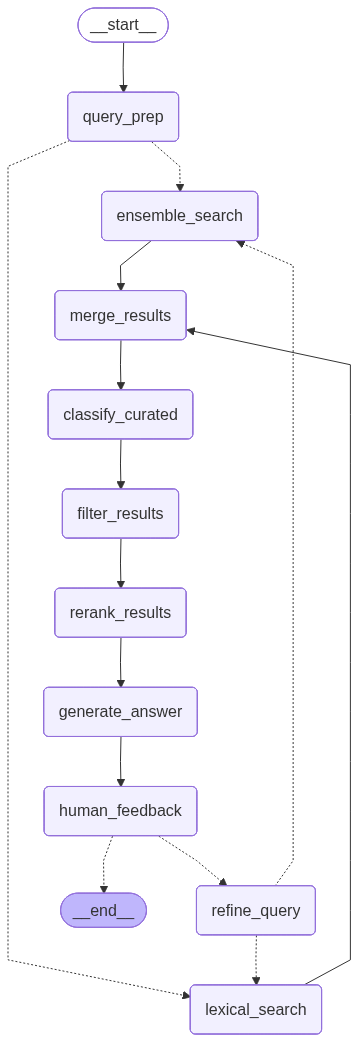

In [12]:
from IPython.display import Image, display

display(Image(orchestrator.get_graph().draw_mermaid_png()))

## 9. Test Queries

Three representative queries that exercise the two routing paths.  All use the default
`top_k=10`.  Pass `top_k=N` to `run_query` to get more or fewer results.

| Query | Expected route | Why |
|---|---|---|
| Natural language (deep learning) | `ensemble` | Natural language phrasing — default route |
| Keyword-only ("pytorch transformers") | `lexical` | Literally just keywords, no sentence structure |
| Conceptual (probability / Bayesian) | `ensemble` | Conceptual query — default route |

The helper function `run_query(query, top_k=10)` prints each pipeline stage so we can
inspect what the keyword extractor, synonym generator, supervisor, retriever(s), and
listwise reranker all produced.

In [13]:
def run_query(query: str, top_k: int = 10) -> dict:
    """Run a query through the orchestrator and display intermediate state.

    Args:
        query:  Natural language or keyword query.
        top_k:  Number of results to return after reranking (default 10).
                Retrievers always over-fetch (RETRIEVER_K candidates) internally.
    """
    print("=" * 70)
    print(f"QUERY: {query}  [top_k={top_k}]")
    print("=" * 70)

    # Each run_query call gets a unique thread ID so checkpointer state is isolated
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    initial_state: OrchestratorState = {
        "query":              query,
        "keywords":           [],
        "expansions":         [],
        "bm25_terms":         [],
        "route":              "",
        "include_curated":    False,
        "bm25_results":       [],
        "vector_results":     [],
        "merged_results":     [],
        "top_k":              top_k,
        "answer":             "",
        # Feedback loop fields (unused in non-interactive run_query)
        "feedback":           {},
        "blocklist":          [],
        "good_repos":         [],
        "feedback_iteration": 0,
    }

    # invoke() returns at the human_feedback interrupt — answer is already set
    result = orchestrator.invoke(initial_state, config)

    print(f"\n--- Keywords extracted : {result['keywords']}")
    print(f"--- BM25 synonym terms : {result['bm25_terms'][:5]} ... ({len(result['bm25_terms'])} total)")
    print(f"--- Route chosen       : {result['route']}")
    print(f"--- Include curated    : {result['include_curated']}")
    print(f"--- BM25 hits          : {len(result['bm25_results'])}")
    print(f"--- Vector hits        : {len(result['vector_results'])}")
    print(f"--- Final results      : {len(result['merged_results'])} repos (top_k={top_k})")
    print()
    print("ANSWER:")
    print(result["answer"])
    print()

    return result

## 10. Interactive Search with Feedback (`run_query_with_feedback`)

Use `run_query_with_feedback(query)` for an **interactive session** where you can
rate each result and iteratively refine the search:

- **☹️ Bad** — Repo is moved to the blocklist; it will never appear again.  
- **😑 Meh** — Kept this round but the agent will try to find better alternatives.  
- **😃 Good** — Pinned: the repo is carried forward into every subsequent round.  

Click **"🔄 Submit & Refine"** to run another search round using your feedback as
positive (😃) and negative (☹️) anchors for LLM query reformulation.  
Click **"✅ I'm Satisfied"** to end the session and keep the current results.

The loop runs for at most **3 feedback rounds** before stopping automatically.

In [14]:
def _display_answer(answer: str) -> None:
    """Render the LLM answer as Markdown in the notebook output."""
    display(Markdown(answer))


def _show_feedback_ui(
    docs: List[Document],
    config: dict,
    iteration: int = 0,
) -> None:
    """Render an ipywidgets rating UI for the given result documents.

    Creates ToggleButton widgets for each repo (☹️ / 😑 / 😃) and two action
    buttons:
    - "🔄 Submit & Refine": sends ratings via Command(resume=...) and runs the
      next search round (up to MAX_FEEDBACK_ROUNDS total).
    - "✅ I'm Satisfied": sends ratings + __stop=True, ending the session.

    Called recursively for each subsequent feedback round.
    """
    round_label = f"Round {iteration + 1} of {MAX_FEEDBACK_ROUNDS}"

    header = widgets.HTML(
        value=(
            f'<h3 style="margin:8px 0 4px;color:#24292f">'
            f'📊 Rate these results — {round_label}</h3>'
            f'<p style="margin:0 0 12px;color:#57606a;font-size:0.9em">'
            f'Rate each result, then <b>Submit &amp; Refine</b> to find better matches '
            f'or <b>I\'m Satisfied</b> when done.</p>'
        )
    )

    rating_toggles: dict = {}
    repo_rows = []

    for doc in docs:
        m    = doc.metadata
        repo = m.get("repo", "unknown")
        url  = m.get("url") or f"https://github.com/{repo}"
        desc = (m.get("description") or "")
        desc_short = desc[:110] + "…" if len(desc) > 110 else desc
        stars = m.get("stars")
        stars_str = f"&nbsp;⭐ {stars:,}" if isinstance(stars, (int, float)) and stars else ""

        label = widgets.HTML(
            value=(
                f'<div style="padding:2px 0">'
                f'<b><a href="{url}" target="_blank" style="color:#0366d6;text-decoration:none">'
                f'{repo}</a></b>'
                f'<span style="color:#888;font-size:0.82em">{stars_str}</span><br/>'
                f'<span style="color:#555;font-size:0.88em">{desc_short}</span>'
                f'</div>'
            )
        )
        toggle = widgets.ToggleButtons(
            options=[("☹️  Bad", "bad"), ("😑  Meh", "meh"), ("😃  Good", "good")],
            value="meh",
            style={"button_width": "100px"},
            layout=widgets.Layout(margin="2px 0 4px 0"),
        )
        rating_toggles[repo] = toggle
        repo_rows.append(
            widgets.VBox(
                [label, toggle],
                layout=widgets.Layout(
                    margin="4px 0",
                    padding="10px 14px",
                    border="1px solid #e1e4e8",
                    border_radius="6px",
                ),
            )
        )

    submit_btn = widgets.Button(
        description="🔄 Submit & Refine",
        button_style="primary",
        layout=widgets.Layout(width="200px", margin="10px 8px 10px 0"),
    )
    done_btn = widgets.Button(
        description="✅ I'm Satisfied",
        button_style="success",
        layout=widgets.Layout(width="180px", margin="10px 0"),
    )
    status_out = widgets.Output()

    def _collect_ratings() -> dict:
        return {repo: toggle.value for repo, toggle in rating_toggles.items()}

    def on_submit(b):
        submit_btn.disabled = True
        done_btn.disabled   = True
        ratings = _collect_ratings()

        with status_out:
            clear_output()
            print("⏳ Refining search based on your feedback…")

        try:
            new_result = orchestrator.invoke(Command(resume=ratings), config)
        except Exception as exc:
            with status_out:
                clear_output()
                print(f"❌ Refinement error: {exc}")
            submit_btn.disabled = False
            done_btn.disabled   = False
            return

        new_iter = new_result.get("feedback_iteration", iteration + 1)

        # Check BEFORE entering the output context so the logic is clean
        snap = orchestrator.get_state(config)
        still_running = bool(snap.next)

        with status_out:
            clear_output()
            print(f"\n{'─'*70}")
            print(f"Refined results — round {new_iter}:")
            print(f"{'─'*70}\n")
            _display_answer(new_result["answer"])

            # IMPORTANT: display() calls inside widget button callbacks MUST be
            # inside an Output widget context to render reliably in JupyterLab.
            # Calling display() here (inside `with status_out:`) guarantees the
            # next feedback widget appears in the already-visible output area.
            if still_running:
                _show_feedback_ui(
                    new_result["merged_results"],
                    config,
                    iteration=new_iter,
                )
            else:
                print("\n✅ No further rounds available.")

    def on_done(b):
        submit_btn.disabled = True
        done_btn.disabled   = True
        ratings = _collect_ratings()
        ratings["__stop"] = True   # signal human_feedback → END

        with status_out:
            clear_output()
            print("⏳ Finalising results…")

        try:
            final_result = orchestrator.invoke(Command(resume=ratings), config)
        except Exception as exc:
            with status_out:
                clear_output()
                print(f"❌ Error: {exc}")
            return

        with status_out:
            clear_output()
            print("\n✅ Session complete. Final results:\n")
            _display_answer(final_result["answer"])

    submit_btn.on_click(on_submit)
    done_btn.on_click(on_done)

    ui = widgets.VBox(
        [header]
        + repo_rows
        + [widgets.HBox([submit_btn, done_btn]), status_out],
        layout=widgets.Layout(max_width="860px"),
    )
    display(ui)


def run_query_with_feedback(query: str, top_k: int = 10) -> dict:
    """Run a query through the orchestrator with an interactive ipywidgets feedback UI.

    The graph pauses at `human_feedback` after the first search round.
    The returned dict is the state at the first interrupt — use the widget UI
    to iterate.  The function also returns the config dict so you can resume
    manually if needed.

    Args:
        query:  Natural language or keyword query.
        top_k:  Number of results to show per round (default 10).
    """
    print("=" * 70)
    print(f"QUERY: {query}  [top_k={top_k}]")
    print("=" * 70)

    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    initial_state: OrchestratorState = {
        "query":              query,
        "keywords":           [],
        "expansions":         [],
        "bm25_terms":         [],
        "route":              "",
        "include_curated":    False,
        "bm25_results":       [],
        "vector_results":     [],
        "merged_results":     [],
        "top_k":              top_k,
        "answer":             "",
        "feedback":           {},
        "blocklist":          [],
        "good_repos":         [],
        "feedback_iteration": 0,
    }

    # First invocation — stops at human_feedback interrupt; answer is already set
    result = orchestrator.invoke(initial_state, config)

    print(f"\n--- Keywords : {result['keywords']}")
    print(f"--- Route    : {result['route']}")
    print(f"--- Results  : {len(result['merged_results'])} repos\n")
    _display_answer(result["answer"])

    # Show the feedback widget UI
    _show_feedback_ui(result["merged_results"], config, iteration=0)

    return result

In [15]:
# Test 1 — Natural language query (expects 'ensemble')
result1 = run_query_with_feedback("What are some top deep learning libraries I have starred?")

QUERY: What are some top deep learning libraries I have starred?  [top_k=10]
[query_prep] keywords=['deep learning', 'libraries']  route='ensemble'  include_curated=False  reason: The query is a natural language question regarding specific libraries, which makes it suitable for the 'ensemble' route, and it does not ask for a list explicitly.
[classify_curated] regex: 8 curated, 1 not-curated, 18 ambiguous
[classify_curated] LLM: 2/18 ambiguous flagged as curated
[filter_results] removed 0 blocklisted + 10 curated-list repo(s), 17 candidates remaining
[reranker] 17 candidates → top 10 after reranking

--- Keywords : ['deep learning', 'libraries']
--- Route    : ensemble
--- Results  : 10 repos



1. [tensorflow/tensorflow](https://github.com/tensorflow/tensorflow)  
   An Open Source Machine Learning Framework for Everyone.  
   This is one of the most prominent libraries for deep learning, enabling developers to create and train advanced neural networks. Its popularity and robustness make it essential for anyone interested in deep learning.

2. [google-deepmind/sonnet](https://github.com/google-deepmind/sonnet)  
   TensorFlow-based neural network library.  
   Sonnet provides a high-level interface for building neural networks with TensorFlow, making it easier to develop complex architectures in deep learning projects.

3. [google-deepmind/dm-haiku](https://github.com/google-deepmind/dm-haiku)  
   JAX-based neural network library.  
   This library is designed for building neural networks using JAX, which emphasizes flexibility and performance, tailored for deep learning research.

4. [BVLC/caffe](https://github.com/BVLC/caffe)  
   Caffe: a fast open framework for deep learning.  
   Caffe is well-known for its speed and modularity in deep learning applications, particularly in computer vision tasks.

5. [dmlc/dgl](https://github.com/dmlc/dgl)  
   Python package built to ease deep learning on graph, on top of existing DL frameworks.  
   DGL focuses on deep learning tasks involving graph structures, making it a valuable tool for those working on graph neural networks and related applications.

6. [neuralmagic/sparseml](https://github.com/neuralmagic/sparseml)  
   Libraries for applying sparsification recipes to neural networks with a few lines of code, enabling faster and smaller models.  
   This library helps optimize deep learning models through sparsification techniques, which can be particularly beneficial for deploying lightweight models.

7. [online-ml/deep-river](https://github.com/online-ml/deep-river)  
   A library focusing on incremental learning in deep learning applications.  
   Though newer, it addresses modern challenges in deep learning, particularly in adapting models to new data streams.

8. [ourownstory/neural_prophet](https://github.com/ourownstory/neural_prophet)  
   NeuralProphet: A simple forecasting package.  
   This package leverages neural networks for time series forecasting, bridging deep learning with traditional forecasting techniques.

9. [The-AI-Summer/Deep-Learning-In-Production](https://github.com/The-AI-Summer/Deep-Learning-In-Production)  
   Build, train, deploy, scale and maintain deep learning models.  
   This resource helps practitioners implement deep learning in real-world applications, covering infrastructure and deployment strategies.

10. [Nyandwi/machine_learning_complete](https://github.com/Nyandwi/machine_learning_complete)  
   A comprehensive machine learning repository containing 30+ notebooks on different concepts, algorithms and techniques.  
   While broad in scope, it includes numerous deep learning examples, making it an excellent learning resource for deep learning enthusiasts.

In [17]:
# Test 2 — Keyword-only query (expects 'lexical')
result2 = run_query_with_feedback("pytorch transformers")

QUERY: pytorch transformers  [top_k=10]
[query_prep] keywords=['pytorch', 'transformers']  route='lexical'  include_curated=False  reason: The query consists of bare keywords without sentences or verbs, so a lexical route is appropriate.
[classify_curated] regex: 3 curated, 1 not-curated, 24 ambiguous
[classify_curated] LLM: 4/24 ambiguous flagged as curated
[filter_results] removed 0 blocklisted + 8 curated-list repo(s), 20 candidates remaining
[reranker] 20 candidates → top 10 after reranking

--- Keywords : ['pytorch', 'transformers']
--- Route    : lexical
--- Results  : 10 repos



1. [huggingface/transformers](https://github.com/huggingface/transformers)  
   This repository provides the model-definition framework for advanced machine learning models across various modalities, including text and vision, using PyTorch. It is highly relevant to your query as it specifically addresses the usage of transformers in PyTorch and supports state-of-the-art NLP tasks.  
   - Language: Python  
   - Stars: 157,250  

2. [codertimo/BERT-pytorch](https://github.com/codertimo/BERT-pytorch)  
   This repository contains an implementation of Google's BERT model using PyTorch, focusing on natural language processing tasks. It's pertinent for those looking to understand or implement BERT with PyTorch transformers directly.  
   - Language: Python  
   - Stars: 6,516  

3. [NVIDIA-Merlin/Transformers4Rec](https://github.com/NVIDIA-Merlin/Transformers4Rec)  
   This library is designed for building recommendation systems using transformer models in PyTorch, specifically for sequential data. It’s relevant as it showcases the application of transformers in AI-driven recommendation systems.  
   - Language: Python  
   - Stars: 1,251  

4. [alibaba/EasyNLP](https://github.com/alibaba/EasyNLP)  
   EasyNLP is a user-friendly toolkit for natural language processing that leverages transformer models. It’s suitable for anyone interested in applying transformers for diverse NLP tasks using PyTorch.  
   - Language: Python  
   - Stars: 2,180  

5. [facebookresearch/fairseq](https://github.com/facebookresearch/fairseq)  
   This is a sequence-to-sequence learning toolkit that supports various sequence modeling tasks and is built with PyTorch. It is relevant for users looking to perform advanced deep learning tasks with transformer models.  
   - Language: Python  
   - Stars: 32,169  

6. [graykode/nlp-tutorial](https://github.com/graykode/nlp-tutorial)  
   This repository contains tutorials for understanding natural language processing with deep learning, including content on transformers. It is useful for researchers new to the field looking to grasp how transformers fit into NLP.  
   - Language: Jupyter Notebook  
   - Stars: 14,864  

7. [cdpierse/transformers-interpret](https://github.com/cdpierse/transformers-interpret)  
   This repository focuses on model interpretability, allowing users to explain their transformer models easily. It’s significant for those wanting to not only use transformers but also to understand their workings better.  
   - Language: Jupyter Notebook  
   - Stars: 1,413  

8. [jalammar/ecco](https://github.com/jalammar/ecco)  
   Ecco is a tool for explaining and visualizing transformer-based language models, valuable for both research and educational purposes to understand model behavior. This can complement your work with PyTorch transformers by providing insights into model interactions.  
   - Language: Jupyter Notebook  
   - Stars: 2,084  

9. [pyg-team/pytorch_geometric](https://github.com/pyg-team/pytorch_geometric)  
   This library is aimed at graph neural networks and provides tools compatible with PyTorch, which may be beneficial if you're looking to extend transformer models into graph-based contexts.  
   - Language: Python  
   - Stars: 23,517  

10. [sktime/pytorch-forecasting](https://github.com/sktime/pytorch-forecasting)  
    This repository focuses on time series forecasting using PyTorch, which may not directly relate to transformers but is useful for anyone interested in temporal modeling applications in AI.  
    - Language: Python  
    - Stars: 4,799  

In [18]:
# Test 3 — Conceptual / exploratory query (expects 'semantic' or 'both')
result3 = run_query_with_feedback("Do I have repos that help me understand probability and Bayesian reasoning?")

QUERY: Do I have repos that help me understand probability and Bayesian reasoning?  [top_k=10]
[query_prep] keywords=['probability', 'Bayesian', 'reasoning']  route='ensemble'  include_curated=False  reason: The query is conceptual, seeking repositories related to specific topics in probability and Bayesian reasoning, not simple keywords, hence 'ensemble' is appropriate.
[classify_curated] regex: 1 curated, 1 not-curated, 19 ambiguous
[classify_curated] LLM: 8/19 ambiguous flagged as curated
[filter_results] removed 0 blocklisted + 9 curated-list repo(s), 12 candidates remaining
[reranker] 12 candidates → top 10 after reranking

--- Keywords : ['probability', 'Bayesian', 'reasoning']
--- Route    : ensemble
--- Results  : 10 repos



1. [pymc-devs/pymc](https://github.com/pymc-devs/pymc)  
   This repository provides tools for Bayesian modeling and probabilistic programming in Python. It is highly relevant as it encompasses Bayesian inference, allowing users to build statistical models and analyze uncertainties.

2. [mckinsey/causalnex](https://github.com/mckinsey/causalnex)  
   A library designed for inferring causation, moving beyond mere correlation. This can help enhance your understanding of Bayesian networks and causal inference, core aspects of Bayesian reasoning.

3. [hyosubkim/bayes-toolbox](https://github.com/hyosubkim/bayes-toolbox)  
   This toolbox focuses on Bayesian statistics and provides various probabilistic programming tools. It is useful for deepening your understanding of Bayesian inference and statistical analysis.

4. [bambinos/bambi](https://github.com/bambinos/bambi)  
   Bambi is an interface for Bayesian model-building in Python, facilitating regression modeling and statistical analyses. This is relevant to learning about Bayesian statistical models and their applications.

5. [cognica-io/bayesian-bm25](https://github.com/cognica-io/bayesian-bm25)  
   This repository offers Bayesian probability transforms particularly for BM25 scoring in information retrieval. It can broaden your understanding of probability applications in search algorithms.

6. [bayesian-optimization/BayesianOptimization](https://github.com/bayesian-optimization/BayesianOptimization)  
   Provides a Python implementation for global optimization using Gaussian processes. This highlights practical applications of Bayesian concepts in optimization problems.

7. [pyro-ppl/numpyro](https://github.com/pyro-ppl/numpyro)  
   A probabilistic programming framework leveraging JAX, capable of efficient computations and flexibility in modeling. It demonstrates advanced techniques in Bayesian inference.

8. [blei-lab/edward](https://github.com/blei-lab/edward)  
   This repository features a probabilistic programming language based on TensorFlow, focusing on deep generative models and variational inference, relevant for advanced Bayesian modeling.

9. [jmschrei/pomegranate](https://github.com/jmschrei/pomegranate)  
   Fast and flexible probabilistic modeling in Python, useful for various machine learning applications. This can provide insights into probabilistic graphical models and their uses.

10. [IntelLabs/causality-lab](https://github.com/IntelLabs/causality-lab)  
    This lab focuses on algorithms for discovering causal relationships. It complements Bayesian reasoning by enhancing understanding of causality in data analysis.